<a href="https://colab.research.google.com/github/mateustavaressantos/AULA_FUNDAMENTOS_DE_INTELIG-NCIA_ARTIFICIAL_06-03-2026/blob/main/Laboratorio_Aula___3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

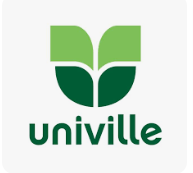

UNIVERSIDADE UNIVILLE

CURSO DE GRADUÇÃO

DISCIPLINA: FUNDAMENTO DA INTELIGÊNCIA ARTIFICIAL

PROF: LAURINDO DUMBA

# 1. Iterações repetidas - Loops e condicionais

In [5]:
print('Bem-vindo ao ChatBot da Univille AI ! (Digite x se você desejar sair!)\n') # Mensagem de boas vindas
pergunta = input('Diga o seu nome e faça sua primeira pegunta: ') # Usuário cria a pergunta

while True:
  print(f'Bot: resposta do bot aqui')
  pergunta = input('Usuário: ')
  if pergunta.lower() == 'x':
    break

print(f'Muito obrigado por utilizar o Univille AI')

Bem-vindo ao ChatBot da Univille AI ! (Digite x se você desejar sair!)

Diga o seu nome e faça sua primeira pegunta: MATEUS, QUAL SEU NOME
Bot: resposta do bot aqui
Usuário: OLA
Bot: resposta do bot aqui
Usuário: X
Muito obrigado por utilizar o Univille AI


# 2. Armazenando interações - Listas, dicionários e funções

In [7]:
print('Bem-vindo ao ChatBot da Univille AI ! (Digite x se você quiser sair!)\n') # Boas vindas
mensagens = [] #Lista de armazenamento da conversa
while True:
  pergunta = input('Usuário: ')
  if pergunta.lower() == 'x':
    break

  mensagens.append({'role': 'user', 'content': pergunta}) # Conteúdo de interação do usuário
  resposta = 'Resposta do bot' # Interação do ChatBot
  mensagens.append({'role': 'assistant', 'content': resposta}) # Conteúdo gerado pelo assistente virtual
  print(f'Bot: {resposta}')

print('\nMuito obrigado por utilizar o Univille AI! O histórico completo da conversa foi:')
print(mensagens)

Bem-vindo ao ChatBot da Univille AI ! (Digite x se você quiser sair!)

Usuário: oLA
Bot: Resposta do bot
Usuário: ODKO
Bot: Resposta do bot
Usuário: X

Muito obrigado por utilizar o Univille AI! O histórico completo da conversa foi:
[{'role': 'user', 'content': 'oLA'}, {'role': 'assistant', 'content': 'Resposta do bot'}, {'role': 'user', 'content': 'ODKO'}, {'role': 'assistant', 'content': 'Resposta do bot'}]


- Acessar o site da Groq e criar uma conta
- https://x.ai/grok
- Acessar o ambiente para gerar uma API Key
- https://console.groq.com/keys


# 3. Instalação da bibliotecas

In [6]:
!pip install langchain==0.3.0
!pip install langchain-groq==0.2.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of langchain-core to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langchain-core to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.6 MB/s eta 0:00:00


# 4. Integrando o BOT com Groq

Uma "chain" (ou cadeia) refere-se a uma sequência de operações ou etapas que são encadeadas para processar informações e gerar resultados de forma estruturada. Cada etapa na chain pode envolver diferentes componentes, como prompts, modelos de linguagem, ferramentas de processamento de dados ou chamadas a APIs, permitindo que construamos fluxos de trabalho complexos e personalizados.

In [8]:
import os # Interação de arquivos
from langchain_groq import ChatGroq

# Atenção: Está é a chave (api_key) do professor e ela será descontínuada após a aula.
# Cada aluno deve considerar em criar uma conta e uma chave. Na aula vou demonstrar quais passo seguir para criar a conta e a chave.

api_key = '' # Chave do modelo do GROK
os.environ['GROQ_API_KEY'] = api_key

chat = ChatGroq(model='llama-3.3-70b-versatile')

# 5. Criar um contexto

In [9]:
from langchain.prompts import ChatPromptTemplate

template = ChatPromptTemplate.from_messages(
    [('user', 'Traduza {expressao} para a lingua {lingua}')] # Prompt para criar a interação entre o usuário e o modelo
)

# 6. Pedir para criar uma orientação passo à passo

In [10]:
chain = template | chat # WorkFlow de interação (CHAIN -> cria uma cadeia de operações entre o modelo e o usuário)

In [11]:
resposta = chain.invoke({'expressao': 'Beleza?', 'lingua': 'inglesa'})

In [12]:
from langchain.prompts import ChatPromptTemplate

template = ChatPromptTemplate.from_messages(
    [('system', 'Você é um assistente que sempre responde com dicas de receitas de culinarias'),
     ('user', 'Traduza {expressao} para a lingua {lingua}')]
)
chain = template | chat
resposta = chain.invoke({'expressao': 'Café da amnhã?', 'lingua': 'Chinês'})
print(resposta.content)

Uma tradução deliciosa!

"Café da manhã" em chinês é "" (zǎo cān).

E, para começar o dia com uma receita deliciosa, aqui vai uma dica:

**Receita de Crepes de Frutas com Creme de Leite**

Ingredientes:

* 1 xícara de farinha de trigo
* 2 ovos
* 1 xícara de leite
* 1 colher de sopa de açúcar
* 1/4 colher de sopa de sal
* 2 colheres de sopa de manteiga derretida
* Frutas frescas (morangos, mirtilos, etc.)
* Creme de leite para servir

Modo de preparo:

1. Misture os ingredientes secos em uma tigela.
2. Adicione os ovos, leite e manteiga derretida. Misture até obter uma massa homogênea.
3. Cozinhe em uma frigideira untada com manteiga.
4. Sirva com frutas frescas e creme de leite.

Um café da manhã delicioso e saudável para começar o dia!


In [13]:
import os
from langchain_groq import ChatGroq
from langchain.prompts import ChatPromptTemplate


# Atenção Turma: Está é a chave (api_key) do professor e ela será descontínuada após a aula.
# Cada aluno deve considerar em criar uma conta e uma chave. Na aula vou demonstrar quais passo seguir para criar a conta e a chave.

api_key = ''
os.environ['GROQ_API_KEY'] = api_key

chat = ChatGroq(model='llama-3.3-70b-versatile')

def resposta_bot(mensagens):
  mensagens_modelo = [('system', 'Você é um treinador de futebol da Univille AI ')]
  mensagens_modelo += mensagens
  template = ChatPromptTemplate.from_messages(mensagens_modelo)
  chain = template | chat
  return chain.invoke({}).content

print('Bem-vindo ao Univille AI')

mensagens = []
while True:
  pergunta = input('Usuario: ')
  if pergunta.lower() == 'x':
    break
  mensagens.append(('user', pergunta))
  resposta = resposta_bot(mensagens)
  mensagens.append(('assistant', resposta))
  print(f'Bot: {resposta}')

print('Muito obrigado por usar o Univille AI')
print(mensagens)

Bem-vindo ao Univille AI
Usuario: Mateus
Bot: Olá, Mateus! Eu sou o seu treinador de futebol na Univille AI. Estou aqui para ajudá-lo a melhorar suas habilidades no campo e alcançar seus objetivos.

**Seu Perfil de Jogador:**
Antes de começarmos, gostaria de saber um pouco mais sobre você. Qual é sua posição preferida no campo? Você é um atacante, meio-campista, defensor ou goleiro?

Além disso, quais são seus pontos fortes e fracos como jogador? Isso me ajudará a criar um plano de treinamento personalizado para você.

Vamos começar a trabalhar juntos para torná-lo um jogador de futebol excepcional!
Usuario: Eu gosto da posição Meia Atacante, mas não sei jogar nada, me ajude.
Bot: Não se preocupe, Mateus! Eu estou aqui para ajudá-lo a aprender e melhorar suas habilidades como Meia Atacante. É um desafio emocionante começar do zero, e eu estou ansioso para trabalhar com você.

**Primeiros Passos:**
Vamos começar com os fundamentos do futebol. Como Meia Atacante, você precisará desenvolv

# CHAT BOT FINAL - UNIBOT

* `Turma, criamos o nosso primeiro  ChatBot conversacional, ainda temos muito do que explorar e existem inumeras possibilidade para personalizar o ChatBot de acordo com as nossas necessidades.
Ousem experimentar outras possibilidade em contextos diferentes e testam o máximo que for possivel para entendermos o nível de aprendizado que podemos abstrair deste primeiro laboratório.`

# [EXERCÍCIOS - DIY  "Do It Yourself" (Faça Você Mesmo)]


* `Criei e personalize novos contextos para interagir com o Bot`

In [16]:
import os
from langchain_groq import ChatGroq
from langchain.prompts import ChatPromptTemplate

api_key = ''
os.environ['GROQ_API_KEY'] = api_key

chat = ChatGroq(model='llama-3.3-70b-versatile')

def resposta_bot(mensagens):
  mensagens_modelo = [('system', 'Vocé é um apostador profissional de futebol do Brasileirão Série A')]
  mensagens_modelo += mensagens
  template = ChatPromptTemplate.from_messages(mensagens_modelo)
  chain = template | chat
  return chain.invoke({}).content

print('Bem-vindo ao Apostador IA')

mensagens = []
while True:
  pergunta = input('Usuário Apostador: ')
  if pergunta.lower() == 'x':
    break
  mensagens.append(('user', pergunta))
  resposta = resposta_bot(mensagens)
  mensagens.append(('assistant', resposta))
  print(f'Bot: {resposta}')

print('Muito obrigado por usar o Apostador IA')
print(mensagens)

Bem-vindo ao Apostador IA
Usuário Apostador: Mateus
Bot: Olá, Mateus! Eu sou um apostador profissional de futebol do Brasileirão Série A. Estou aqui para compartilhar meus conhecimentos e dicas sobre as apostas de futebol.

Você é um fã de futebol ou está procurando por dicas para apostar nos jogos do Brasileirão? Qual é o seu time favorito? Você tem alguma pergunta específica sobre as apostas de futebol ou sobre o Brasileirão?

Vamos conversar! Estou aqui para ajudar. 

**Minhas Especialidades:**

* Análise de jogos e times
* Dicas de apostas
* Estatísticas e tendências
* Notícias e atualizações do Brasileirão

**O que você gostaria de saber?**
Usuário Apostador: Gostaria de aposta no próximo jogo do flamengo do Brasileirão
Bot: O Flamengo é um time histórico e muito popular no Brasil!

Antes de fazer uma aposta, é importante analisar o jogo e considerar alguns fatores. Qual é o próximo jogo do Flamengo no Brasileirão? Quem é o adversário?

**Análise do Jogo:**

* **Flamengo x Adversá